# EXOPLANETARY DATA ANALYSIS

**Data:** NASA EXOPLANET ARCHIVE
**Author:** AYUSH
**Date:** 2026

## INTRODUCTION

This project uses the data from NASA Exoplanetary archive to analyze various characteristics and behaviors of confirmed exoplanets , the goal of this analysis is to use real world data to visualize and prove fundamental astrophysics concepts


## SETUP AND LOADING DATA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/planetary_data.csv', comment='#')



## 1. EXOPLANET DISCOVERY RATE

*"How has the rate of planet discovery changed over the years"*

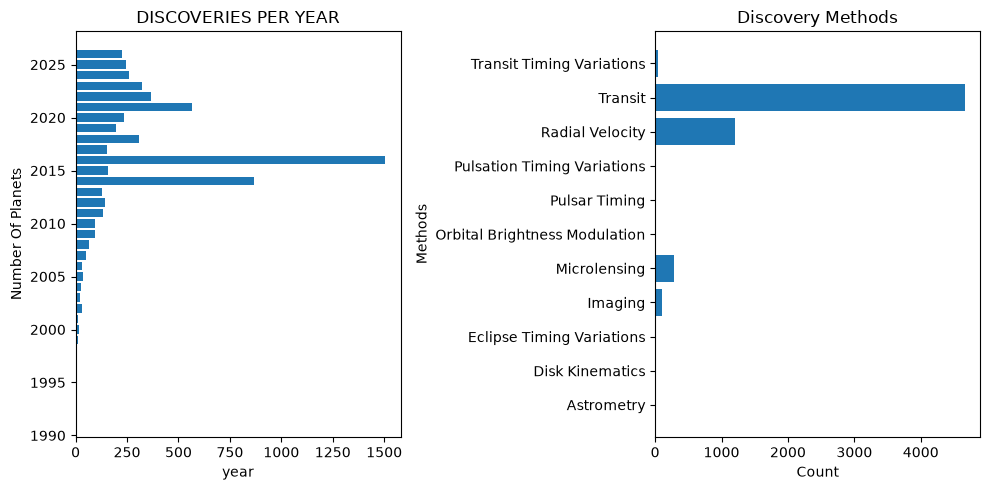

In [4]:
years = df.groupby('disc_year').size()
method = df.groupby('discoverymethod').size()

fig, axes = plt.subplots(1,2 , figsize =(10, 5))

axes[0].barh( years.index , years.values)
axes[0].set_title("DISCOVERIES PER YEAR")
axes[0].set_xlabel("year")
axes[0].set_ylabel("Number Of Planets")

axes[1].barh(method.index , method.values)
axes[1].set_title("Discovery Methods")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Methods")


plt.tight_layout()

### Observation
exoplanet discovery has been sparse until 2009 with the launch of the Keppler Space Telescope and the data dump in 2016

## 2. PLANETARY SIZE DISTRIBUION

*"what is the statistical distribution of planet sizes and give evidence of distinct planet classes like super-earths and sub-neptunes"*

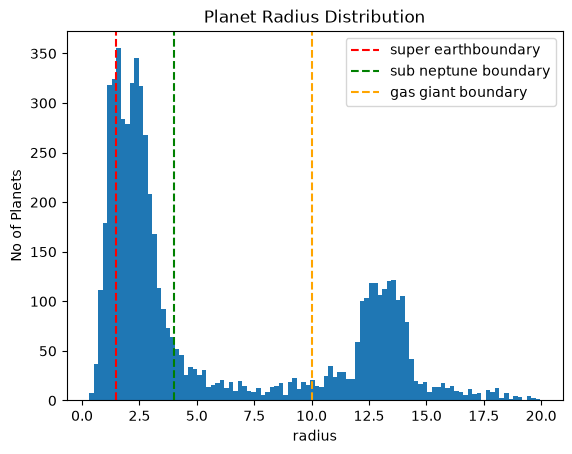

In [5]:
rad = df['pl_rade'].dropna()

radius = rad[rad <= 20]

plt.hist(radius.values , bins =100)
plt.axvline(x = 1.5, color='red',linestyle = '--' ,label ='super earthboundary')
plt.axvline(x = 4, color='green',linestyle = '--' ,label ='sub neptune boundary')
plt.axvline(x = 10, color='orange',linestyle = '--' ,label ='gas giant boundary')
plt.legend()
plt.title("Planet Radius Distribution")
plt.xlabel("radius")
plt.ylabel("No of Planets")
plt.show()

### Observation

This distribution reveals two distinct classes of exoplanents- 
 1.5 to 2.5 earth radii (Super-earths) & 12 to 14 earth radii (Gas Giants) 

**The absence of planetes between 4-10 earth is known as the Fulton Gap likely cauesd due to photoevaporation stripping away the planetary atmosphere** 

## 3. MASS V/S RADIUS 

*"Does mass vs radius relation follow the theoritical predictions also can distinct planetary compositions be identified from this relationship alone"*

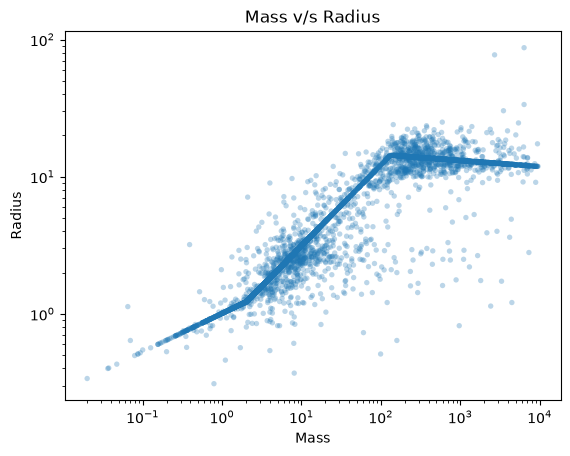

In [10]:
data = df[['pl_rade' , 'pl_bmasse']].dropna()

plt.scatter(data.pl_bmasse,  data.pl_rade , alpha=0.3, s = 15 , edgecolors='none')
plt.xlabel("Mass")
plt.ylabel("Radius")
plt.title("Mass v/s Radius")
plt.xscale('log')
plt.yscale('log')

### Observation

We can see that the mass v/s radius graph is linear until we reach the higher mass values when it flattens out , gas giants get significantly massive without getting much larger due to gravitatonal compression . The cluster of data also acts as evidence for distinct planet classes.  

## 4.HABITABLE ZONE 

**"how many planets lie in the habitable zone i.e. they can "*sustain liquid water on their surfaces*

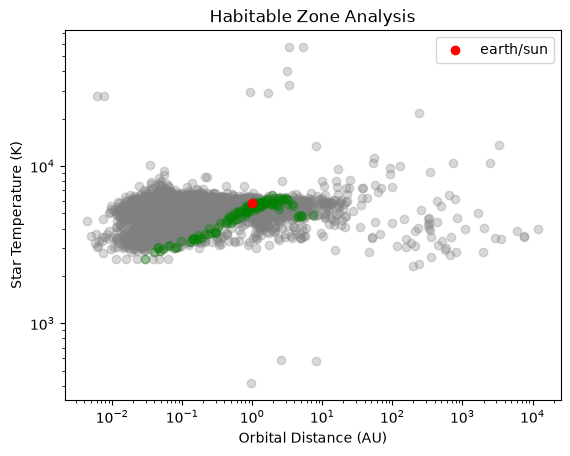

Total habitable zone planets found: 125
Earth-sized (0.8-1.25 Earth radii) in HZ: 7


In [7]:
df = df.copy()

data = df[['pl_orbsmax' , 'st_teff']]
R_sun = 6.957e8
L_sun = 3.828e26



df['st_rad_m'] = df['st_rad'] * R_sun
L = 4 * np.pi * (df['st_rad_m']) ** 2 * (5.67e-8) * (df['st_teff'])**4
L_solar = L / L_sun
r_inner = np.sqrt(L_solar / 1.1)
r_outer = np.sqrt(L_solar / 0.53)

df['hz'] = (df['pl_orbsmax'] >= r_inner) & (df['pl_orbsmax'] <= r_outer)

hz_range = df[df['hz'] == True]

plt.scatter(data.pl_orbsmax , data.st_teff , alpha=0.3,color='gray')
plt.scatter(hz_range['pl_orbsmax'] , hz_range['st_teff'] , alpha=0.3,color='green')
plt.scatter(1.0, 5778 , color='red', label='earth/sun')
plt.xlabel('Orbital Distance (AU)')
plt.ylabel('Star Temperature (K)')
plt.title('Habitable Zone Analysis')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()
 
print(f'Total habitable zone planets found: {len(hz_range)}')
print(f'Earth-sized (0.8-1.25 Earth radii) in HZ: {len(hz_range[(hz_range["pl_rade"] >= 0.8) & (hz_range["pl_rade"] <= 1.25)])}')


### Observation

Using the Stefan-Boltzmann law to calculate the stellar luminosity to further derive the thermal boundaries and plot the planets that lie in this region in green
which reveals that the hotter the star is the further the planet needs to be for it to be habitable as vice versa.
Earth is used as a reference point which also sits in the habitable zone validating the approach
further earth sized planets have been filtered out which come out to be 7.

## 5. DISCOVERY METHOD DOMINANCE


**"which method of exoplanet discovery has been the most dominant in the history of astronomy"**

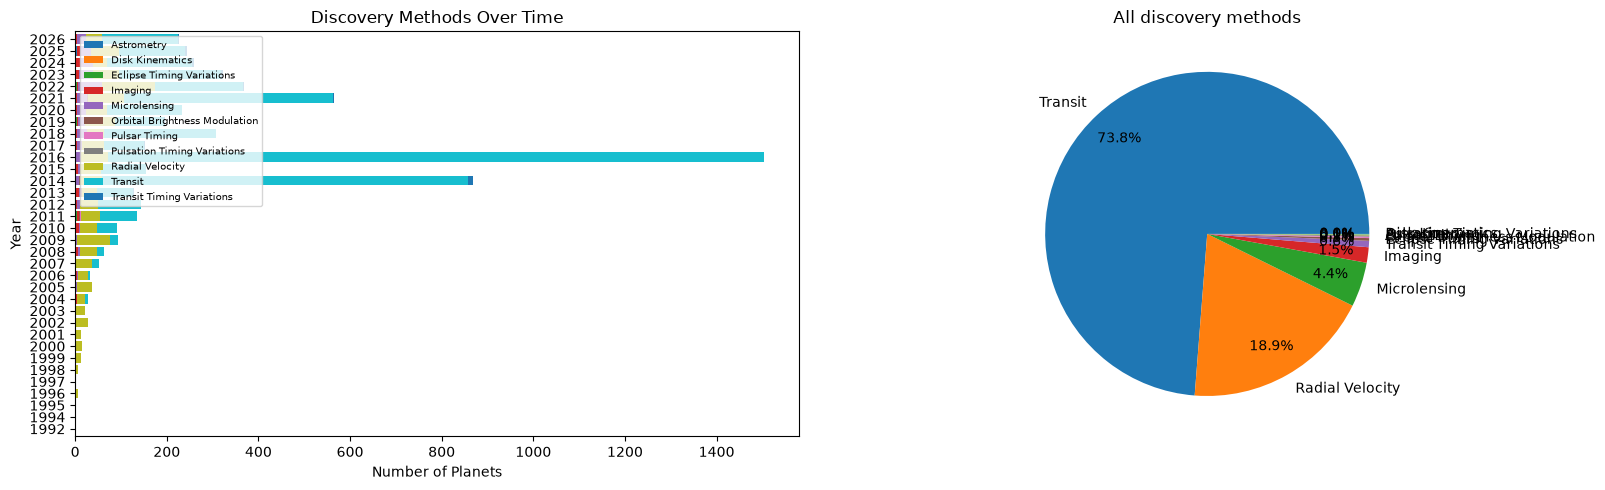

In [8]:
dm = df.groupby(['disc_year' , 'discoverymethod']).size().unstack(fill_value=0)

methoddata = df['discoverymethod'].value_counts()

fig ,axes = plt.subplots(1,2,figsize=(16,5))

dm.plot(kind = 'barh', stacked=True , ax=axes[0], width =0.8 )
axes[0].set_title('Discovery Methods Over Time')
axes[0].set_xlabel('Number of Planets')
axes[0].set_ylabel('Year')
axes[0].legend(loc='upper left', fontsize=7)

plt.tight_layout()


axes[1].pie(methoddata, labels = methoddata.index , autopct='%1.1f%%' , pctdistance=0.8, labeldistance=1.1)

axes[1].set_title("All discovery methods")
plt.show()

### Observation

Transit method is responsible for 73.8% of all confirmed exoplanet discoveries almost entirely driven by the kepler mission before which radial velocity was main method which accounts for 9 percent of the total discoveries.

## Conclusion

This analysis of 6316 confirmed exoplanets revealed very interesting details and further validated basic astrophysics principles.

Some key insights to be noted from this are

- the significance of the Keppler Mission in the discovery of exoplanets 
- the Fulton Gap that exists due to photoevaporation of the planetary atmosphere
- the potentially habitable candidates across various stellar types